# Classification of handwritten digits using various neural network models with PyTorch
* Multinomial classification task of images of handwritten digits (10 classes).
* The database has a training set of 60k examples, and a test set of 10k examples, each image is of 28x28 pixels size.
* The MNIST ("Modified National Institute of Standards and Technology") is the “hello world” dataset for computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms.

## Model setup

Before we start we need to load libraries and setup the model parameters

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

model_args = {}
# random seed
model_args['seed'] = 123
# we will use batch size of 128 in Stochastic Gradient Descent (SGD) optimization of the network
model_args['batch_size'] = 128
# learning rate is how fast it will descend
model_args['lr'] = .05
# SGD momentum (default: .5) momentum is a moving average of gradients (it helps to keep direction)
model_args['momentum'] = .5
# the number of epochs is the number of times you go through the full dataset
model_args['epochs'] = 50
# logging frequency
model_args['log_interval'] = 100

Let's start with loading the dataset and check how it looks like

In [23]:
# load the MINST dataset via torchvision
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transform)
# we divide this data into training and validation subsets
train_subset, validation_subset = torch.utils.data.random_split(mnist_train, [50000, 10000])
test_subset = datasets.MNIST('../data', train=False, download=True, transform=transform)

In [24]:
# define dataloaders
loader_kwargs = {'batch_size': model_args['batch_size'],
                 'num_workers': 2,
                 'pin_memory': True,
                 'shuffle': True}
train_loader = torch.utils.data.DataLoader(train_subset, **loader_kwargs)
validation_loader = torch.utils.data.DataLoader(validation_subset, **loader_kwargs)
test_loader = torch.utils.data.DataLoader(test_subset, **loader_kwargs)

Plot sample images

50000
10000
10000
391
torch.Size([28, 28])


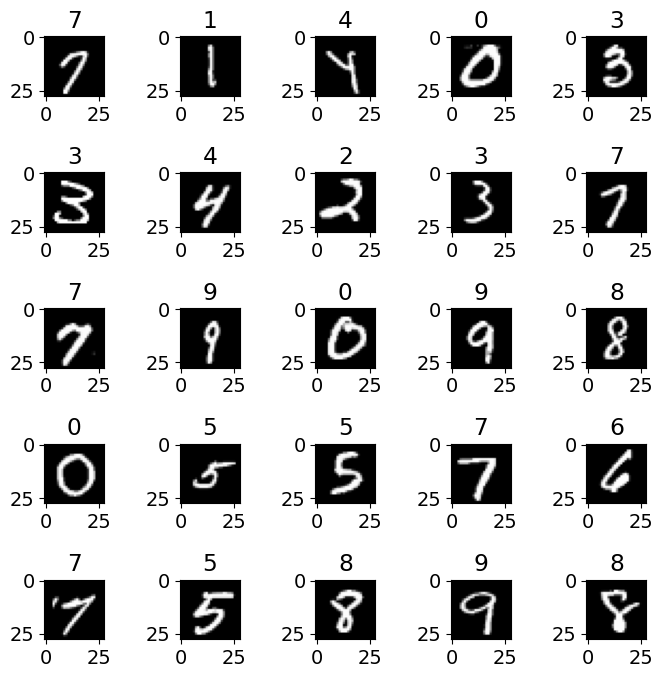

In [25]:
print(len(train_subset))
print(len(validation_subset))
print(len(test_subset)) # we have data already divided into train & validation & test subsets
print(len(train_loader)) # no of train batches
example_number = 123
print(train_subset[example_number][0][0].shape) # single item shape

fig, axs = plt.subplots(5, 5, figsize=(7,7), tight_layout=True)
for i in range(5):
    for j in range(5):
        axs[i,j].imshow(train_subset[example_number+i*5+j][0].reshape(28,28), cmap='gray')
        axs[i,j].set_title(train_subset[example_number+i*5+j][1])

Let's now construct the NN model: deep **convolutional neural network**.

**Change 1: Dropout probability has been added to model**

In [26]:
class CNN(nn.Module):
    # this defines the structure of the CNN model
    def __init__(self, p_dropout):
        self.p_dropout = p_dropout 
        super(CNN, self).__init__()
        # convolutional layer with 2 kernels of size 5x5
        self.conv1 = nn.Conv2d(1, 2, kernel_size=5)
        # 4 kernels of size 5x5
        self.conv2 = nn.Conv2d(2, 4, kernel_size=5)
        # 2D dropout
        self.conv2_drop = nn.Dropout2d()
        # fully connected layers
        self.fc1 = nn.Linear(64, 20)
        self.fc2 = nn.Linear(20, 10)

    def forward(self, x):
        # 1st layers group
        x = self.conv1(x) # resulting in 2 feature maps each of size 24x24
        x = F.max_pool2d(x, 2) # downsizing each map to 12x12
        x = F.relu(x) # standard (in CNNs) ReLU activation
        # 2nd group
        x = self.conv2(x) # resulting in 4 feature maps each of size 8x8
        # x = self.conv2_drop(x)
        x = F.max_pool2d(x, 2) # downsizing each map to 4x4
        x = F.relu(x)
        # fully connected layers
        x = x.view(-1, 64) # 4 maps of 4x4 size gives 64 numbers
        x = self.fc1(x) # 64 -> 20
        x = F.relu(x)
        x = F.dropout(x, p=self.p_dropout, training=self.training) # dropout is a type of regularization
        x = self.fc2(x) # 20 -> 10
        # softmax (multinomial classification) gives probabilities of each class
        return F.log_softmax(x, dim=1) # note that dim=0 is the number of samples in batch


And define training, testing, and plotting utils:

In [27]:
def train(model, device, train_loader, optimizer, epoch_number):
    model.train()
    train_loss = 0.
    # get subsequent batches over the data in a given epoch
    for batch_idx, (data, target) in enumerate(train_loader):
        # send data tensors to GPU (or CPU)
        data, target = data.to(device), target.to(device)
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # this will execute the forward() function
        output = model(data)
        # calculate the negative-log-likelihood loss
        loss = F.nll_loss(output, target, reduction='mean')
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        if batch_idx % model_args['log_interval'] == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch_number, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
        train_loss += loss.item()
    train_loss /= len(train_loader)
    print('\nTrain set: Average loss: {:.4f}'.format(train_loss))
    return train_loss

def test(model, device, test_loader, message):
    model.eval()
    test_loss = 0.
    correct = 0
    # this is just inference, we don't need to calculate gradients
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            # calculate and sum up batch loss
            test_loss += F.nll_loss(output, target, reduction='mean')
            # get the index of class with the max log-probability
            prediction = output.argmax(dim=1)
            # item() returns value of the given tensor
            correct += prediction.eq(target).sum().item()
    test_loss /= len(test_loader)
    print('{}: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        message, test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    return test_loss.cpu()

def plot_loss(train_loss, validation_loss, title):
    plt.grid(True)
    plt.xlabel("subsequent epochs")
    plt.ylabel('average loss')
    plt.plot(range(1, len(train_loss)+1), train_loss, 'o-', label='training')
    plt.plot(range(1, len(validation_loss)+1), validation_loss, 'o-', label='validation')
    plt.legend()
    plt.title(title)
    plt.show()

## Experiments

3. Compare these results with a deep convolutional network, which is more useful in real-world problems:

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.298975
Train Epoch: 1 [12800/50000 (26%)]	Loss: 1.606995
Train Epoch: 1 [25600/50000 (51%)]	Loss: 0.822970
Train Epoch: 1 [38400/50000 (77%)]	Loss: 0.941870

Train set: Average loss: 1.1836
Validation set: Average loss: 0.3959, Accuracy: 8692/10000 (87%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 0.672226
Train Epoch: 2 [12800/50000 (26%)]	Loss: 0.787683
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.674171
Train Epoch: 2 [38400/50000 (77%)]	Loss: 0.627623

Train set: Average loss: 0.6900
Validation set: Average loss: 0.2487, Accuracy: 9326/10000 (93%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 0.588703
Train Epoch: 3 [12800/50000 (26%)]	Loss: 0.588071
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.515826
Train Epoch: 3 [38400/50000 (77%)]	Loss: 0.620032

Train set: Average loss: 0.6018
Validation set: Average loss: 0.2132, Accuracy: 9366/10000 (94%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 0.581321
Train Epoch: 4 [12800/50000 (26%)]	Loss: 0.452724
Train Epoch: 4 [25600/5

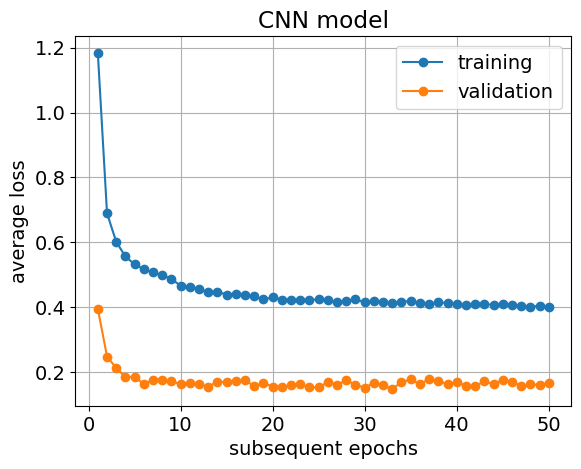

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(p_dropout=0.5).to(device)

optimizer = optim.SGD(model.parameters(), lr=model_args['lr'], momentum=model_args['momentum'])
#optimizer = optim.Adadelta(model.parameters(), lr=model_args['lr'])

torch.manual_seed(model_args['seed'])
train_loss = []
validation_loss = []
for epoch_number in range(1, model_args['epochs'] + 1):
    train_loss.append(train(model, device, train_loader, optimizer, epoch_number))
    validation_loss.append(test(model, device, validation_loader, 'Validation set'))

test(model, device, test_loader, 'Test set')
plot_loss(train_loss, validation_loss, 'CNN model')

**Change 2: Set dropout to 0 so effectively turning off regularization**

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.292907
Train Epoch: 1 [12800/50000 (26%)]	Loss: 0.608479
Train Epoch: 1 [25600/50000 (51%)]	Loss: 0.242088
Train Epoch: 1 [38400/50000 (77%)]	Loss: 0.371581

Train set: Average loss: 0.5964
Validation set: Average loss: 0.2152, Accuracy: 9362/10000 (94%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 0.159562
Train Epoch: 2 [12800/50000 (26%)]	Loss: 0.262249
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.174715
Train Epoch: 2 [38400/50000 (77%)]	Loss: 0.147115

Train set: Average loss: 0.1792
Validation set: Average loss: 0.1618, Accuracy: 9524/10000 (95%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 0.142197
Train Epoch: 3 [12800/50000 (26%)]	Loss: 0.159703
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.078681
Train Epoch: 3 [38400/50000 (77%)]	Loss: 0.137523

Train set: Average loss: 0.1366
Validation set: Average loss: 0.1351, Accuracy: 9573/10000 (96%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 0.091151
Train Epoch: 4 [12800/50000 (26%)]	Loss: 0.055563
Train Epoch: 4 [25600/5

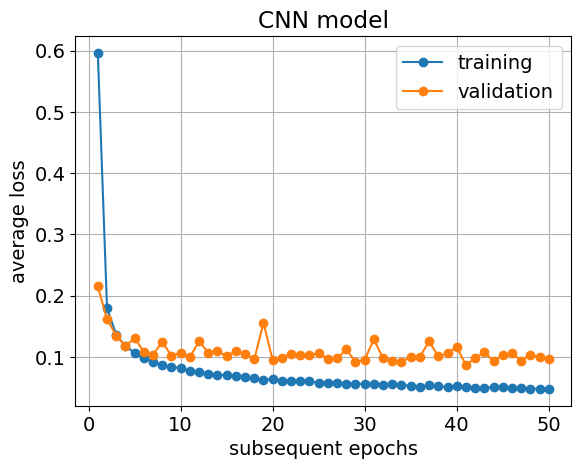

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN(p_dropout=0.0).to(device)

optimizer = optim.SGD(model.parameters(), lr=model_args['lr'], momentum=model_args['momentum'])
#optimizer = optim.Adadelta(model.parameters(), lr=model_args['lr'])

torch.manual_seed(model_args['seed'])
train_loss = []
validation_loss = []
for epoch_number in range(1, model_args['epochs'] + 1):
    train_loss.append(train(model, device, train_loader, optimizer, epoch_number))
    validation_loss.append(test(model, device, validation_loader, 'Validation set'))

test(model, device, test_loader, 'Test set')
plot_loss(train_loss, validation_loss, 'CNN model')

## Summary
* *Deep* and *CNN* models with accuracies of 96% and 97% (evaluated on the test subset) perform much better than single-layer *Perceptron* with 92%;
* The two smallest (and simplest) models appear to be overfitted. To deal with this we need to apply some regularization.
* Validation subset is evaluated during the training (as opposed to test set, infered *after* the training) in order to tune the model hiperparameters (that describe e.g. the network structure, or training details).
* A moment to stop trainning is a kind of hipermarameter -- by applying *early stopping* we can avoid overfitting.



## Tasks to do
* apply some regularization technique to *Deep* model in order to avoid overfitting (start with nonzero *weight_decay* in optimizer)
* try to figure out why the validation loss for *CNN* model turns to be *lower* than the train loss (hint: turn off regularization),
* **tune one of these models to get the *Test Set Accuracy* > 99%**,
* plot the *confusion matrix* among all of the classes---which of digits are mostly confused with each other?
>How to build the confusion matrix?
> * for example 1st row represents images with "0" digit (*ground truth*), while 1st colum images for which the model *predicts* "0",
> * this way element _11 is equal to number of images with "0" corectly clasified as "0" (true positives), while _15 means number of images with "0" wrongly calssified as "4", and so on.